<a href="https://colab.research.google.com/github/BeanQueso/passwords-dsrp/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
ai_digital_media = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/AI%20and%20Digital%20Media/Global_AI_Content_Impact_Dataset.csv")

first_valid_year = {
    'Bard': 2023,
    'ChatGPT': 2022,
    'Claude': 2023,
    'DALL-E': 2021,
    'Midjourney': 2022,
    'Stable Diffusion': 2022,
    'Synthesia': 2020
}

mismatch_count = 0
check_list = []

for index, row in ai_digital_media.iterrows():
    tool = row['Top AI Tools Used']
    year = row['Year']

    if year < first_valid_year[tool]:
        mismatch_count += 1
        check_list.append(row)

print(mismatch_count)

72


In [23]:
ai_digital_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

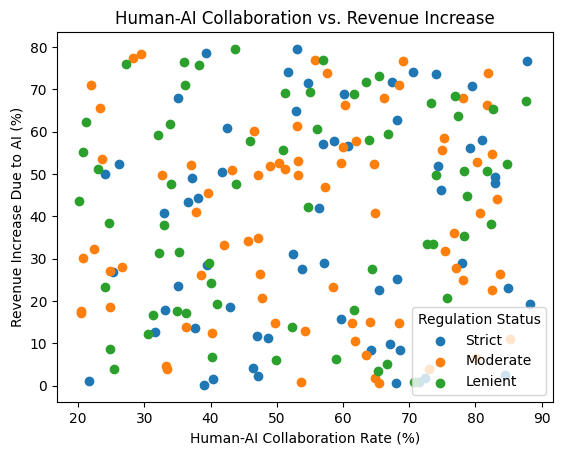

In [25]:
for status in ai_digital_media['Regulation Status'].unique():
    data = ai_digital_media[
        ai_digital_media['Regulation Status'] == status
    ]

    plt.scatter(
        data['Human-AI Collaboration Rate (%)'],
        data['Revenue Increase Due to AI (%)'],
        label=status
    )

plt.title('Human-AI Collaboration vs. Revenue Increase')
plt.xlabel('Human-AI Collaboration Rate (%)')
plt.ylabel('Revenue Increase Due to AI (%)')
plt.legend(title='Regulation Status')
plt.show()